# FoldTree2 Geometry-Focused Decoder Notebook

This refactor focuses on geometric supervision and reconstruction quality:

1. Validate quaternion logic and frame conversions.
2. Compare geometric losses (FAPE variants, quaternion losses, delta loss).
3. Visualize structural outputs (Ramachandran, angle traces, 3D reconstructions).
4. Run a tiny smoke-test training loop with a frozen (pretrained-if-available) encoder,
   a Transformer geometry decoder, and an SE(3) structure decoder.


In [1]:
%load_ext autoreload
%autoreload 2

import os
import math
import random
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import tqdm
from torch_geometric.loader import DataLoader
from torch_geometric.data import HeteroData

from foldtree2.src import pdbgraphmk2
from foldtree2.src import encoder as ecdr
from foldtree2.src.losses.fape import (
	rotation_matrix_to_quaternion,
	quaternion_to_rotation_matrix,
	reconstruct_positions,
	differentiable_lddt_loss as lddt_coord_loss,
	fape_loss as rt_fape_loss,
)

from foldtree2.src.losses.losses import (
	quaternion_geodesic_loss,
	quaternion_angle_loss,
	quaternion_fape_loss,
)

try:
	from foldtree2.src.se3_struct_decoder import Transformer_Geometry_Decoder, se3_denoiser
	SE3_GRAPH_DECODER_AVAILABLE = True
except Exception as exc:
	from foldtree2.src.mono_decoders import Transformer_Geometry_Decoder
	se3_denoiser = None
	SE3_GRAPH_DECODER_AVAILABLE = False
	warnings.warn(f"SE3 graph decoder import failed; falling back to mono decoder: {exc}")

SE3_AVAILABLE = se3_denoiser is not None

# se3_struct_decoder sets global default float64; reset to float32 for the main training path.
torch.set_default_dtype(torch.float32)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

In [2]:
# Centralized notebook configuration: edit values here.
NB_CFG = {
    'use_se3': False,  # Set to True to enable SE3 decoder and related loss terms; requires se3_struct_decoder to be available.
	'seed': 42,
	'preferred_cuda_index': 1,
	'repo_root_fallback': '/home/dmoi/projects/foldtree2',
	'dataset_relpath': 'structs_training_mk2.h5',
	'train_loader': {
		'batch_size': 2,
		'shuffle': True,
		'num_workers': 0,
	},
	'angle_rad_threshold': 3.5,
	'pretrained': {
		'encoder_state_path': 'models/notebook/final_30char_mk2_contacts_aa_encoder_epoch_4.pth',
		'encoder_full_path': 'models/notebook/final_30char_mk2_contacts_aa_encoder_full_epoch_4.pt',
		'decoder_state_path': 'models/notebook/final_30char_mk2_contacts_aa_decoder_epoch_4.pth',
		'decoder_full_path': 'models/notebook/final_30char_mk2_contacts_aa_decoder_full_epoch_4.pt',
	},
	'encoder_fallback_out_dim': 64,
	'contact': {
		'threshold_default': 0.65,
		'threshold_train': 0.65,
	},
	'positional_encoding_dim': 256,
	'optim': {
		'lr': 1e-4,
		'weight_decay': 1e-5,
		'grad_clip_max_norm': 1.0,
	},
	'loss_weights': {
		'fape_quat': 0.1,
		'quat_geodesic': 0.1,
		'lddt_coords': 0.1,
		'distogram': 0.10,
		'neighbor': 0.10,
		'cross_prod_random': 0.10,
		'angles': 0.10,
		'neighbor_se3': 0.10,
		'quat_geodesic_se3': 0.10,
		'fape_quat_se3': 0.10,
        'cross_prod': 0.10,
	},
	'distogram': {
		'pairs_per_graph': 1024,
		'no_bins': 16,
		'min_bin': 2.0,
		'max_bin': 21.0,
		'temperature': 1.0,
		'label_smoothing': 0.0,
		'min_seq_sep': 2,
	},
	'transformer_decoder': {
		'hidden_channels': [128, 64, 32],
		'nheads': 4,
		'layers': 2,
		'rt_hidden': [128, 64, 32],
		'angles_hidden': [128, 64, 32],
		'dropout': 0.05,
		'normalize': True,
		'residual': True,
		'learn_positions': True,
		'output_rt': True,
		'output_ss': False,
		'output_angles': True,
		'internal_dim': 32,
		'edge_dim': 1,
	},

	'medium_decoder': {
		'transformer_hidden_channels': [64, 32, 16],
		'transformer_nheads': 2,
		'transformer_layers': 2,
		'transformer_rt_hidden': [64, 32, 16],
		'transformer_ss_hidden': [32, 16, 8],
		'transformer_angles_hidden': [32, 32, 16],
		'transformer_dropout': 0.05,
		'transformer_learn_positions': False,
		'se3_hidden': [8],
		'se3_out_channels': 6,
		'se3_num_embeddings': 30,
		'se3_commitment_cost': 0.25,
		'se3_edge_dim': 1,
		'se3_depth': 2,
		'se3_heads': 2,
		'se3_dim_head': 8,
		'se3_num_atom_types': 1,
	},
	'mini_train': {
		'n_steps': 3,
		'test_steps': False,
	},
	'probe': {
		'steps': 12,
	},
	'epoch_train': {
		'num_epochs': 1,
		'max_batches_per_epoch': 8,
		'viz_sample_idx': 0,
		'target_effective_batch_size': 10,
		'use_uncertainty_weighting': True,
		'nan_guard': True,
		'uncertainty_term_names': ['fape_quat', 'quat_geodesic', 'lddt_coords', 'distogram', 'angles', 'neighbor', 'cross_prod_random', 'fape_quat_se3', 'quat_geodesic_se3', 'neighbor_se3'],
	},
	'nan_probe': {
		'steps': 512,
		'run_se3': True,
	},
	'long_run': {
		'num_epochs': 20,
		'target_effective_batch_size': 10,
		'use_se3': False,
		'viz_sample_idx': 0,
		'plot_every_n_batches': 1000,
	},
	'viz': {
		'sample_idx': 0,
	},
	'fape_noise': {
		'preferred_structure': 'foldtree2/config/1eei.pdb',
		'fallback_structures': ['tmp/A0CST5.pdb', 'tmp/A0A0C2GTF1.pdb'],
		'noise_stds': [0.0, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0],
		'primary_metric': 'fape_quat',
	},
}

print('Loaded NB_CFG with sections:', sorted(NB_CFG.keys()))

Loaded NB_CFG with sections: ['angle_rad_threshold', 'contact', 'dataset_relpath', 'distogram', 'encoder_fallback_out_dim', 'epoch_train', 'fape_noise', 'long_run', 'loss_weights', 'medium_decoder', 'mini_train', 'nan_probe', 'optim', 'positional_encoding_dim', 'preferred_cuda_index', 'pretrained', 'probe', 'repo_root_fallback', 'seed', 'train_loader', 'transformer_decoder', 'use_se3', 'viz']


In [3]:
# Force cross-product-only training objective for this run.
if 'NB_CFG' not in globals():
    raise RuntimeError('NB_CFG not found. Run Cell 3 first.')

loss_weights = NB_CFG.setdefault('loss_weights', {})
for key in list(loss_weights.keys()):
    if key != 'neighbor_mode':
        loss_weights[key] = 0.0

# Keep only cross-product terms: adjacent-neighbor and random-pair variants.
loss_weights['neighbor'] = 1.0
loss_weights['cross_prod_random'] = 1.0
loss_weights['cross_prod'] = 1.0  # optional compatibility key
loss_weights['neighbor_mode'] = 'neighbor'

# Keep uncertainty weighting focused on active terms.
NB_CFG.setdefault('epoch_train', {})['uncertainty_term_names'] = ['neighbor', 'cross_prod_random']

print('Updated loss_weights for cross-product-only run:')
print(loss_weights)

Updated loss_weights for cross-product-only run:
{'fape_quat': 0.0, 'quat_geodesic': 0.0, 'lddt_coords': 0.0, 'distogram': 0.0, 'neighbor': 1.0, 'cross_prod_random': 1.0, 'angles': 0.0, 'neighbor_se3': 0.0, 'quat_geodesic_se3': 0.0, 'fape_quat_se3': 0.0, 'cross_prod': 1.0, 'neighbor_mode': 'neighbor'}


In [4]:
#create pdb to graph converter from pdbgraphmk2
pdb_to_graph = pdbgraphmk2.PDB2PyG()

In [5]:
cfg = globals().get('NB_CFG', {})
SEED = int(cfg.get('seed', 42))
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

preferred_cuda_index = int(cfg.get('preferred_cuda_index', 1))
if torch.cuda.is_available():
	n_gpu = torch.cuda.device_count()
	if n_gpu > preferred_cuda_index:
		device = torch.device(f'cuda:{preferred_cuda_index}')
	else:
		device = torch.device('cuda:0')
	torch.cuda.set_device(device)
	print('cuda_device_count:', n_gpu)
	print('active_device:', torch.cuda.current_device(), torch.cuda.get_device_name(torch.cuda.current_device()))
else:
	device = torch.device('cpu')

print('device:', device)

cuda_device_count: 2
active_device: 1 NVIDIA RTX PRO 4000 Blackwell
device: cuda:1


In [6]:
cfg = globals().get('NB_CFG', {})
loader_cfg = cfg.get('train_loader', {})
repo_fallback = cfg.get('repo_root_fallback', '/home/dmoi/projects/foldtree2')
dataset_relpath = cfg.get('dataset_relpath', 'structs_training_mk2.h5')
loader_batch_size = int(loader_cfg.get('batch_size', 1))
loader_shuffle = bool(loader_cfg.get('shuffle', True))
loader_num_workers = int(loader_cfg.get('num_workers', 0))

repo_root_candidates = [
	Path.cwd(),
	Path.cwd().parent,
	Path(repo_fallback),
]

repo_root = next(
	(p.resolve() for p in repo_root_candidates if (p / 'pyproject.toml').exists()),
	Path(repo_fallback).resolve(),
)

dataset_path = repo_root / dataset_relpath
if not dataset_path.exists():
	raise FileNotFoundError(f'Requested dataset not found: {dataset_path}')

struct_dat = pdbgraphmk2.StructureDataset(str(dataset_path))
train_loader = DataLoader(struct_dat, batch_size=loader_batch_size, shuffle=loader_shuffle, num_workers=loader_num_workers)
data_sample = next(iter(train_loader)).to(device)

print('cwd:', Path.cwd())
print('repo_root:', repo_root)
print('dataset:', dataset_path)
print('num_samples:', len(struct_dat))
print('batch_size:', loader_batch_size)
print('steps_per_epoch:', math.ceil(len(struct_dat) / loader_batch_size))
print('node types:', data_sample.node_types)
print('edge types:', data_sample.edge_types)

cwd: /home/dmoi/projects/foldtree2/foldtree2/notebooks/experiments
repo_root: /home/dmoi/projects/foldtree2
dataset: /home/dmoi/projects/foldtree2/structs_training_mk2.h5
num_samples: 20090
batch_size: 2
steps_per_epoch: 10045
node types: ['AA', 'R_true', 'bend_bin', 'bondangles', 'burial_bin', 'cbcoords', 'chi', 'contact_number', 'coords', 'fourier1di', 'fourier1dr', 'fourier2di', 'fourier2dr', 'global_contacts', 'godnode', 'godnode4decoder', 'local_contacts', 'plddt', 'positions', 'q_true', 'range_bin', 'res', 'sc_centroid', 'ss', 't_true', 'torsion_bin', 'wcn']
edge types: [('godnode4decoder', 'informs', 'res'), ('godnode', 'informs', 'res'), ('res', 'backbone', 'res'), ('res', 'backbonerev', 'res'), ('res', 'contactPoints', 'res'), ('res', 'informs', 'godnode'), ('res', 'informs', 'godnode4decoder'), ('res', 'window', 'res'), ('res', 'windowrev', 'res')]


In [7]:


def node_x(data, key, default=None):
	if key in data.node_types and hasattr(data[key], 'x') and data[key].x is not None:
		return data[key].x
	return default


def get_true_geometry(data):
	true_R = node_x(data, 'R_true')
	true_t = node_x(data, 't_true')
	true_q = rotation_matrix_to_quaternion(true_R) if true_R is not None else None
	true_angles = node_x(data, 'bondangles')
	true_coords = node_x(data, 'coords')
	plddt = node_x(data, 'plddt')
	batch_idx = data['res'].batch if ('res' in data.node_types and hasattr(data['res'], 'batch')) else None
	return true_R, true_t, true_q, true_angles, true_coords, batch_idx, plddt


def to_np(x):
	if x is None:
		return None
	if isinstance(x, torch.Tensor):
		return x.detach().cpu().numpy()
	return np.asarray(x)




def plot_ramachandran(true_angles, pred_angles):
	ta = to_np(true_angles)
	pa = to_np(pred_angles)
	if ta is None or pa is None:
		print('Ramachandran skipped: missing true/pred angles')
		return

	fig, axes = plt.subplots(1, 2, figsize=(10, 4))
	axes[0].scatter(ta[:, 0], ta[:, 1], s=10, alpha=0.35, c='tab:blue')
	axes[0].set_title('True Ramachandran')
	axes[0].set_xlabel('phi (rad)')
	axes[0].set_ylabel('psi (rad)')
	axes[0].set_xlim(-math.pi, math.pi)
	axes[0].set_ylim(-math.pi, math.pi)

	axes[1].scatter(pa[:, 0], pa[:, 1], s=10, alpha=0.35, c='tab:orange')
	axes[1].set_title('Predicted Ramachandran')
	axes[1].set_xlabel('phi (rad)')
	axes[1].set_ylabel('psi (rad)')
	axes[1].set_xlim(-math.pi, math.pi)
	axes[1].set_ylim(-math.pi, math.pi)

	plt.tight_layout()


def plot_angle_traces(true_angles, pred_angles):
	ta = to_np(true_angles)
	pa = to_np(pred_angles)
	if ta is None or pa is None:
		print('Angle traces skipped: missing true/pred angles')
		return

	labels = ['phi', 'psi', 'omega']
	fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
	for i, ax in enumerate(axes):
		ax.plot(ta[:, i], label=f'true {labels[i]}', alpha=0.8)
		ax.plot(pa[:, i], label=f'pred {labels[i]}', alpha=0.8)
		ax.set_ylabel('rad')
		ax.legend(loc='upper right')
	axes[-1].set_xlabel('residue index')
	plt.tight_layout()


def plot_3d_reconstruction(true_coords, pred_coords, se3_coords=None, edge_indices=None, edge_probs=None):
	tc = to_np(true_coords)
	pc = to_np(pred_coords)
	sc = to_np(se3_coords)
	ei = to_np(edge_indices)
	ep = to_np(edge_probs)

	if tc is None or pc is None:
		print('3D reconstruction skipped: missing coords')
		return

	n_res = min(int(tc.shape[0]), int(pc.shape[0]))
	if n_res <= 0:
		print('3D reconstruction skipped: empty coordinate arrays')
		return
	tc = tc[:n_res]
	pc = pc[:n_res]
	if sc is not None:
		sc = sc[:n_res]

	# Align all curves to a common origin for shape comparison
	tc0 = tc - tc[0]
	pc0 = pc - pc[0]
	sc0 = sc - sc[0] if sc is not None else None

	# True CA distogram from ground-truth coordinates.
	true_distogram = np.linalg.norm(tc[:, None, :] - tc[None, :, :], axis=-1)

	# Build dense edge-probability matrix from sparse decoder outputs.
	edge_prob_mat = None
	if ei is not None and ep is not None:
		ei = np.asarray(ei)
		ep = np.asarray(ep).reshape(-1)
		if ei.ndim == 2 and ei.shape[0] == 2 and ep.shape[0] == ei.shape[1]:
			edge_prob_mat = np.full((n_res, n_res), np.nan, dtype=float)
			for k in range(ei.shape[1]):
				s = int(ei[0, k])
				d = int(ei[1, k])
				if 0 <= s < n_res and 0 <= d < n_res:
					p = float(ep[k])
					old = edge_prob_mat[s, d]
					edge_prob_mat[s, d] = p if np.isnan(old) else max(old, p)
			edge_prob_mat = np.where(np.isnan(edge_prob_mat), edge_prob_mat.T, edge_prob_mat)
			edge_prob_mat = np.where(np.isnan(edge_prob_mat), 0.0, edge_prob_mat)

	fig = plt.figure(figsize=(18, 6))
	ax3d = fig.add_subplot(1, 3, 1, projection='3d')

	ax3d.plot(tc0[:, 0], tc0[:, 1], tc0[:, 2], color='tab:blue', label='true', linewidth=2.0)
	ax3d.plot(pc0[:, 0], pc0[:, 1], pc0[:, 2], color='tab:orange', label='transformer recon', linewidth=1.6)
	if sc0 is not None:
		ax3d.plot(sc0[:, 0], sc0[:, 1], sc0[:, 2], color='tab:green', label='se3 coords', linewidth=1.2)

	ax3d.set_title('3D C-alpha Reconstruction (origin-aligned)')
	ax3d.set_xlabel('x')
	ax3d.set_ylabel('y')
	ax3d.set_zlabel('z')
	ax3d.legend()

	axd = fig.add_subplot(1, 3, 2)
	im_d = axd.imshow(true_distogram, cmap='magma', origin='lower')
	axd.set_title('True Distogram (CA-CA)')
	axd.set_xlabel('Residue index')
	axd.set_ylabel('Residue index')
	fig.colorbar(im_d, ax=axd, fraction=0.046, pad=0.04)

	axe = fig.add_subplot(1, 3, 3)
	if edge_prob_mat is None:
		axe.text(0.5, 0.5, 'edge_probs unavailable', ha='center', va='center')
		axe.set_axis_off()
	else:
		im_e = axe.imshow(edge_prob_mat, cmap='viridis', origin='lower', vmin=0.0, vmax=1.0)
		axe.set_title('Frozen Decoder Edge Probabilities')
		axe.set_xlabel('Residue index')
		axe.set_ylabel('Residue index')
		fig.colorbar(im_e, ax=axe, fraction=0.046, pad=0.04)

	plt.tight_layout()
	plt.show()

In [8]:
# Angle unit + periodicity patch (degrees/radians auto-normalization).
cfg = globals().get('NB_CFG', {})
ANGLE_RAD_THRESHOLD = float(cfg.get('angle_rad_threshold', 3.5))

def wrap_to_pi_torch(x: torch.Tensor) -> torch.Tensor:
	return torch.atan2(torch.sin(x), torch.cos(x))

def maybe_deg_to_rad_torch(angles: torch.Tensor, threshold: float = ANGLE_RAD_THRESHOLD) -> torch.Tensor:
	if angles is None:
		return None
	a = angles.float()
	finite = a[torch.isfinite(a)]
	if finite.numel() == 0:
		return a
	max_abs = float(finite.abs().max().detach().cpu())
	if max_abs > threshold:
		a = torch.deg2rad(a)
	return wrap_to_pi_torch(a)

def maybe_deg_to_rad_np(angles, threshold: float = ANGLE_RAD_THRESHOLD):
	if angles is None:
		return None
	a = np.asarray(angles, dtype=float)
	if a.size == 0:
		return a
	finite = np.isfinite(a)
	if finite.any() and np.nanmax(np.abs(a[finite])) > threshold:
		a = np.deg2rad(a)
	return np.arctan2(np.sin(a), np.cos(a))


# Override geometry extractor to return normalized true angles globally.
def get_true_geometry(data):
	true_R = node_x(data, 'R_true')
	true_t = node_x(data, 't_true')
	true_q = rotation_matrix_to_quaternion(true_R) if true_R is not None else None
	true_angles = maybe_deg_to_rad_torch(node_x(data, 'bondangles'))
	true_coords = node_x(data, 'coords')
	plddt = node_x(data, 'plddt')
	batch_idx = data['res'].batch if ('res' in data.node_types and hasattr(data['res'], 'batch')) else None
	return true_R, true_t, true_q, true_angles, true_coords, batch_idx, plddt

# Override plotting helpers to ensure comparable radian plots.
def plot_ramachandran(true_angles, pred_angles):
	ta = maybe_deg_to_rad_np(to_np(true_angles))
	pa = maybe_deg_to_rad_np(to_np(pred_angles))
	if ta is None or pa is None:
		print('Ramachandran skipped: missing true/pred angles')
		return

	fig, axes = plt.subplots(1, 2, figsize=(10, 4))
	axes[0].scatter(ta[:, 0], ta[:, 1], s=10, alpha=0.35, c='tab:blue')
	axes[0].set_title('True Ramachandran')
	axes[0].set_xlabel('phi (rad)')
	axes[0].set_ylabel('psi (rad)')
	axes[0].set_xlim(-math.pi, math.pi)
	axes[0].set_ylim(-math.pi, math.pi)

	axes[1].scatter(pa[:, 0], pa[:, 1], s=10, alpha=0.35, c='tab:orange')
	axes[1].set_title('Predicted Ramachandran')
	axes[1].set_xlabel('phi (rad)')
	axes[1].set_ylabel('psi (rad)')
	axes[1].set_xlim(-math.pi, math.pi)
	axes[1].set_ylim(-math.pi, math.pi)

	plt.tight_layout()

def plot_angle_traces(true_angles, pred_angles):
	ta = maybe_deg_to_rad_np(to_np(true_angles))
	pa = maybe_deg_to_rad_np(to_np(pred_angles))
	if ta is None or pa is None:
		print('Angle traces skipped: missing true/pred angles')
		return

	labels = ['phi', 'psi', 'omega']
	fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
	for i, ax in enumerate(axes):
		ax.plot(ta[:, i], label=f'true {labels[i]}', alpha=0.8)
		ax.plot(pa[:, i], label=f'pred {labels[i]}', alpha=0.8)
		ax.set_ylabel('rad')
		ax.set_ylim(-math.pi, math.pi)
		ax.legend(loc='upper right')
	axes[-1].set_xlabel('residue index')
	plt.tight_layout()

print('Angle patch active: automatic deg->rad normalization + periodic losses.')

Angle patch active: automatic deg->rad normalization + periodic losses.


In [9]:
import torch.nn as nn
from foldtree2.src import mono_decoders as mcdr

# Keep checkpoint loading and fallback modules in float32 even if prior cells changed global dtype.
torch.set_default_dtype(torch.float32)

cfg = globals().get('NB_CFG', {})
pre_cfg = cfg.get('pretrained', {})
repo_base = Path(repo_root) if 'repo_root' in globals() else Path(cfg.get('repo_root_fallback', '/home/dmoi/projects/foldtree2'))

def _resolve_path(root: Path, p: str) -> Path:
	pp = Path(p)
	return pp if pp.is_absolute() else (root / pp)

PRETRAINED_ENCODER_PATH = _resolve_path(repo_base, pre_cfg.get('encoder_state_path', 'models/notebook/final_30char_mk2_contacts_aa_encoder_epoch_4.pth'))
PRETRAINED_ENCODER_FULL_PATH = _resolve_path(repo_base, pre_cfg.get('encoder_full_path', 'models/notebook/final_30char_mk2_contacts_aa_encoder_full_epoch_4.pt'))

PRETRAINED_DECODER_PATH = _resolve_path(repo_base, pre_cfg.get('decoder_state_path', 'models/notebook/final_30char_mk2_contacts_aa_decoder_epoch_4.pth'))
PRETRAINED_DECODER_FULL_PATH = _resolve_path(repo_base, pre_cfg.get('decoder_full_path', 'models/notebook/final_30char_mk2_contacts_aa_decoder_full_epoch_4.pt'))

class FrozenProjectionEncoder(nn.Module):
	def __init__(self, in_dim, out_dim=64):
		super().__init__()
		self.proj = nn.Sequential(
			nn.LayerNorm(in_dim),
			nn.Linear(in_dim, out_dim),
			nn.GELU(),
			nn.Linear(out_dim, out_dim),
		)

	def forward(self, data):
		x = data['res'].x.float()
		z = self.proj(x)
		return z, torch.zeros((), device=x.device, dtype=x.dtype)


def _load_any_full_model(path: Path):
	path = Path(path)
	payload = torch.load(str(path), map_location='cpu', weights_only=False)
	if isinstance(payload, nn.Module):
		return payload
	if isinstance(payload, dict):
		if isinstance(payload.get('model'), nn.Module):
			return payload['model']
		if isinstance(payload.get('encoder'), nn.Module):
			return payload['encoder']
	raise RuntimeError(f'Could not extract nn.Module from {path}')


def _load_any_full_decoder(path: Path):
	path = Path(path)
	payload = torch.load(str(path), map_location='cpu', weights_only=False)
	if isinstance(payload, nn.Module):
		return payload
	if isinstance(payload, dict):
		if isinstance(payload.get('model'), nn.Module):
			return payload['model']
		if isinstance(payload.get('decoder'), nn.Module):
			return payload['decoder']
	raise RuntimeError(f'Could not extract decoder nn.Module from {path}')


def load_encoder_any(path: Path):
	path = Path(path)
	if not path.exists():
		raise FileNotFoundError(path)

	# Attempt project-native checkpoint loader first
	try:
		model, _, resumed_epoch = ecdr.load_model(str(path))
		return model, {'source': str(path), 'mode': 'ecdr.load_model', 'epoch': resumed_epoch}
	except Exception:
		pass

	payload = torch.load(str(path), map_location='cpu', weights_only=False)

	# Full serialized module
	if isinstance(payload, nn.Module):
		return payload, {'source': str(path), 'mode': 'torch.load(module)', 'epoch': None}

	# Dict-wrapped module
	if isinstance(payload, dict):
		if isinstance(payload.get('model'), nn.Module):
			return payload['model'], {'source': str(path), 'mode': 'payload["model"]', 'epoch': payload.get('epoch')}
		if isinstance(payload.get('encoder'), nn.Module):
			return payload['encoder'], {'source': str(path), 'mode': 'payload["encoder"]', 'epoch': payload.get('epoch')}

		# Pure state_dict case (common for .pth)
		if len(payload) > 0 and all(torch.is_tensor(v) for v in payload.values()):
			if not PRETRAINED_ENCODER_FULL_PATH.exists():
				raise RuntimeError('State-dict checkpoint found, but no full-model template is available.')
			template = _load_any_full_model(PRETRAINED_ENCODER_FULL_PATH)
			missing, unexpected = template.load_state_dict(payload, strict=False)
			return template, {
				'source': str(path),
				'mode': 'state_dict_on_full_template',
				'epoch': None,
				'missing': missing,
				'unexpected': unexpected,
			}

	raise RuntimeError(f'Unsupported encoder checkpoint format in {path}')


def load_decoder_any(path: Path):
	path = Path(path)
	if not path.exists():
		raise FileNotFoundError(path)

	# Attempt project-native checkpoint loader first
	try:
		model, _, resumed_epoch = mcdr.load_model(str(path))
		return model, {'source': str(path), 'mode': 'mcdr.load_model', 'epoch': resumed_epoch}
	except Exception:
		pass

	payload = torch.load(str(path), map_location='cpu', weights_only=False)

	# Full serialized module
	if isinstance(payload, nn.Module):
		return payload, {'source': str(path), 'mode': 'torch.load(module)', 'epoch': None}

	# Dict-wrapped module
	if isinstance(payload, dict):
		if isinstance(payload.get('model'), nn.Module):
			return payload['model'], {'source': str(path), 'mode': 'payload["model"]', 'epoch': payload.get('epoch')}
		if isinstance(payload.get('decoder'), nn.Module):
			return payload['decoder'], {'source': str(path), 'mode': 'payload["decoder"]', 'epoch': payload.get('epoch')}

		# Pure state_dict case (common for .pth)
		if len(payload) > 0 and all(torch.is_tensor(v) for v in payload.values()):
			if not PRETRAINED_DECODER_FULL_PATH.exists():
				raise RuntimeError('State-dict checkpoint found, but no full-decoder template is available.')
			template = _load_any_full_decoder(PRETRAINED_DECODER_FULL_PATH)
			missing, unexpected = template.load_state_dict(payload, strict=False)
			return template, {
				'source': str(path),
				'mode': 'state_dict_on_full_template',
				'epoch': None,
				'missing': missing,
				'unexpected': unexpected,
			}

	raise RuntimeError(f'Unsupported decoder checkpoint format in {path}')


if not PRETRAINED_ENCODER_PATH.exists() and not PRETRAINED_ENCODER_FULL_PATH.exists():
	raise FileNotFoundError(
		f'Neither requested checkpoint exists: {PRETRAINED_ENCODER_PATH} or {PRETRAINED_ENCODER_FULL_PATH}'
	)

encoder = None
load_errors = []
for candidate in [PRETRAINED_ENCODER_PATH, PRETRAINED_ENCODER_FULL_PATH]:
	if not candidate.exists():
		continue
	try:
		encoder, load_info = load_encoder_any(candidate)
		encoder = encoder.to(device).float()
		encoder.eval()
		for p in encoder.parameters():
			p.requires_grad = False

		with torch.no_grad():
			_z_test, _vq_test = encoder(data_sample)
		print(f'Loaded pretrained encoder via {load_info["mode"]} from {load_info["source"]} epoch={load_info.get("epoch")}')
		if 'missing' in load_info or 'unexpected' in load_info:
			print('missing_keys:', len(load_info.get('missing', [])))
			print('unexpected_keys:', len(load_info.get('unexpected', [])))
		break
	except Exception as exc:
		load_errors.append((str(candidate), str(exc)))
		encoder = None

if encoder is None:
	for src, err in load_errors:
		print(f'Encoder load failed for {src}: {err}')
	in_dim = int(data_sample['res'].x.shape[-1])
	fallback_out_dim = int(cfg.get('encoder_fallback_out_dim', 64))
	encoder = FrozenProjectionEncoder(in_dim=in_dim, out_dim=fallback_out_dim).to(device).float()
	encoder.eval()
	for p in encoder.parameters():
		p.requires_grad = False
	print('Using frozen projection encoder fallback for smoke-test integration.')

with torch.no_grad():
	z_probe, vq_probe = encoder(data_sample)

latent_dim = int(z_probe.shape[-1])
print('latent_dim:', latent_dim, 'vq_probe:', float(vq_probe.detach().cpu()))

# Load pretrained pair/contact decoder used for edge probability predictions.
decoder = None
decoder_load_errors = []
for candidate in [PRETRAINED_DECODER_PATH, PRETRAINED_DECODER_FULL_PATH]:
	if not candidate.exists():
		continue
	try:
		decoder, decoder_load_info = load_decoder_any(candidate)
		decoder = decoder.to(device).float()
		decoder.eval()
		for p in decoder.parameters():
			p.requires_grad = False

		print(
			f'Loaded pretrained decoder via {decoder_load_info["mode"]} '
			f'from {decoder_load_info["source"]} epoch={decoder_load_info.get("epoch")}'
		)
		if 'missing' in decoder_load_info or 'unexpected' in decoder_load_info:
			print('decoder missing_keys:', len(decoder_load_info.get('missing', [])))
			print('decoder unexpected_keys:', len(decoder_load_info.get('unexpected', [])))
		break
	except Exception as exc:
		decoder_load_errors.append((str(candidate), str(exc)))
		decoder = None

if decoder is None:
	for src, err in decoder_load_errors:
		print(f'Decoder load failed for {src}: {err}')
	warnings.warn(
		'Could not load pretrained decoder; contact-probability branch will require setting `decoder` manually.'
	)
else:
	print('decoder ready for contact probability inference.')

Loaded pretrained encoder via state_dict_on_full_template from /home/dmoi/projects/foldtree2/models/notebook/final_30char_mk2_contacts_aa_encoder_epoch_4.pth epoch=None
missing_keys: 0
unexpected_keys: 0
latent_dim: 8 vq_probe: 0.0006515828426927328
Loaded pretrained decoder via state_dict_on_full_template from /home/dmoi/projects/foldtree2/models/notebook/final_30char_mk2_contacts_aa_decoder_epoch_4.pth epoch=None
decoder missing_keys: 0
decoder unexpected_keys: 0
decoder ready for contact probability inference.


In [10]:
from torch_geometric.data import HeteroData
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_undirected	

def _build_allpairs_from_batch(batch_idx: torch.Tensor) -> torch.Tensor:
	pairs = []
	for b in torch.unique(batch_idx, sorted=True):
		idx = torch.where(batch_idx == b)[0]
		if idx.numel() == 0:
			continue
		ii = idx.repeat_interleave(idx.numel())
		jj = idx.repeat(idx.numel())
		pairs.append(torch.stack([ii, jj], dim=0))
	if len(pairs) == 0:
		return torch.zeros((2, 0), dtype=torch.long, device=batch_idx.device)
	return torch.cat(pairs, dim=1)

def _quantized_z_from_encoder(enc, data_batch):
	z_raw, _ = enc(data_batch)
	vq = getattr(enc, 'vector_quantizer', None)
	if vq is None:
		return z_raw.detach()
	ords = vq.discretize_z(z_raw.detach())
	if isinstance(ords, (tuple, list)):
		ords = ords[0]
	ords = ords.detach().view(-1).long()
	return vq.embeddings(ords) , ords

def build_minimal_contact_graph_batch(data_batch, enc, contact_pair_decoder, threshold, converter_obj, device_obj):
	cfg = globals().get('NB_CFG', {})
	pos_enc_dim = int(cfg.get('positional_encoding_dim', 256))

	with torch.no_grad():
		z_quant , ords = _quantized_z_from_encoder(enc, data_batch)
		z_quant = z_quant.to(device_obj, dtype=torch.float32)
		ords = ords.to(device_obj, dtype=torch.long)

	batch_idx = data_batch['res'].batch if hasattr(data_batch['res'], 'batch') else torch.zeros(z_quant.shape[0], dtype=torch.long, device=device_obj)
	allpairs = _build_allpairs_from_batch(batch_idx).to(device_obj)

	pair_data = data_batch.clone().to(device_obj)
	pair_data['res'].x = z_quant

	with torch.no_grad():
		pair_out = contact_pair_decoder(pair_data, allpairs)

	edge_scores = pair_out.get('edge_probs', None)
	if edge_scores is None:
		raise RuntimeError("Contact decoder must provide 'edge_probs' for the selected allpairs.")

	edge_scores = edge_scores.to(device_obj).reshape(-1)
	if edge_scores.shape[0] != allpairs.shape[1]:
		raise RuntimeError(f"edge_probs length ({edge_scores.shape[0]}) does not match allpairs ({allpairs.shape[1]}).")

	mask = edge_scores > threshold
	edge_indices = allpairs[:, mask]
	edge_probs = edge_scores[mask]

	minimal = HeteroData()
	minimal['ords'].x = ords
	minimal['ords'].batch = batch_idx
	minimal['res'].x = z_quant
	minimal['res'].batch = batch_idx
	minimal['plddt'] = data_batch['plddt']
	minimal['positions'] = data_batch['positions']
	minimal['res', 'contact_proba', 'res'].edge_index = torch.tensor(edge_indices.detach().clone(), dtype=torch.long, device=device_obj)
	minimal['res', 'contact_proba', 'res'].edge_attr = edge_probs.detach().clone().unsqueeze(-1).float()
	minimal['res', 'backbone', 'res'] = data_batch['res', 'backbone', 'res']
	minimal['res', 'backbone_rev', 'res'] = data_batch['res', 'backbone_rev', 'res']

	#to undirected
	#minimal = to_undirected(minimal)
	minimal = minimal.to(device_obj)

	return minimal, edge_indices, edge_probs



In [11]:
#loss postfix
def _loss_postfix(name):
	return f'_{name}' if name else ''

In [12]:
cfg = globals().get('NB_CFG', {})
td_cfg = cfg.get('transformer_decoder', {})
se3_cfg = cfg.get('se3_min', {})

# Autoreload can re-import modules that set global default dtype; force float32 before instantiating decoder layers.
torch.set_default_dtype(torch.float32)

transformer_geom_decoder = Transformer_Geometry_Decoder(
	in_channels={'res': 16},
	hidden_channels={('res', 'backbone', 'res'): td_cfg.get('hidden_channels', [128, 64, 32])},
	concat_positions=True,
	nheads=int(td_cfg.get('nheads', 8)),
	layers=int(td_cfg.get('layers', 2)),
	RTdecoder_hidden=td_cfg.get('rt_hidden', [128, 64, 32]),
	ssdecoder_hidden=td_cfg.get('ss_hidden', [128, 64, 32]),
	anglesdecoder_hidden=td_cfg.get('angles_hidden', [128, 64, 32]),
	dropout=float(td_cfg.get('dropout', 0.05)),
	normalize=bool(td_cfg.get('normalize', True)),
	residual=bool(td_cfg.get('residual', False)),
	learn_positions=bool(td_cfg.get('learn_positions', True)),
	output_rt=bool(td_cfg.get('output_rt', True)),
	output_ss=bool(td_cfg.get('output_ss', False)),
	output_angles=bool(td_cfg.get('output_angles', True)),
	internal_dim=int(td_cfg.get('internal_dim', 128)),
	edge_dim=int(td_cfg.get('edge_dim', 1)),
).to(device).float()

# Infer SE3 input width from first geometry decoder embedding output ('z').
_contact_pair_decoder = globals().get('decoder', None)
if _contact_pair_decoder is None:
	raise RuntimeError('Missing pretrained pair decoder `decoder`; run Cell 9 first.')
_contact_cfg = cfg.get('contact', {})
_contact_threshold = float(globals().get('contact_thresh', _contact_cfg.get('threshold_default', 0.6)))
_converter_obj = globals().get('converter', pdb_to_graph)

with torch.no_grad():
	_init_geom_data = data_sample.clone().to(device)
	_init_minimal_data, _init_edge_indices, _init_edge_probs = build_minimal_contact_graph_batch(
		data_batch=_init_geom_data,
		enc=encoder,
		contact_pair_decoder=_contact_pair_decoder,
		threshold=_contact_threshold,
		converter_obj=_converter_obj,
		device_obj=device,
	)
	# Keep decoder inputs in float32 to avoid matmul dtype mismatch in position MLP.
	if 'positions' in _init_minimal_data.node_types and hasattr(_init_minimal_data['positions'], 'x') and _init_minimal_data['positions'].x is not None:
		_init_minimal_data['positions'].x = _init_minimal_data['positions'].x.to(device=device, dtype=torch.float32)
	if ('res', 'contact_proba', 'res') in _init_minimal_data.edge_types and hasattr(_init_minimal_data['res', 'contact_proba', 'res'], 'edge_attr') and _init_minimal_data['res', 'contact_proba', 'res'].edge_attr is not None:
		_init_minimal_data['res', 'contact_proba', 'res'].edge_attr = _init_minimal_data['res', 'contact_proba', 'res'].edge_attr.to(device=device, dtype=torch.float32)
	print(_init_minimal_data)
	_init_geom_out = transformer_geom_decoder(
		_init_minimal_data,
		contact_pred_index=_init_edge_indices,
		contact_probs=_init_edge_probs,
	)
	_init_se3_in = _init_geom_out.get('z', _init_minimal_data['res'].x)
se3_in_channels = int(_init_se3_in.shape[-1])
se3_device = device if device.type == 'cuda' else torch.device('cpu')

first_param = next(transformer_geom_decoder.parameters(), None)
if first_param is not None:
	print('transformer_geom_decoder dtype:', first_param.dtype)

Seed set to 42


Transformer_Geometry_Decoder(SE3Graph): d_model=32, backbone_layers=1, layers=2, contact_threshold=0.05, max_neighbors=32, translation_limit=20.0, head_kernel_size=5, use_mhc=False, mhc_streams=1


AttributeError: 'Transformer_AA_Decoder' object has no attribute 'use_mhc'

In [ ]:
from contextlib import nullcontext

from foldtree2.src.losses.losses import angles_reconstruction_loss, quaternion_angle_loss, quaternion_geodesic_loss, quaternion_fape_loss
from foldtree2.src.losses.fape import differentiable_lddt_loss
from foldtree2.src.losses.fape import distogram_loss_from_coords
from foldtree2.src.losses.fape import cross_product_loss

# Full training loop with adjustable epochs and per-epoch recon visualizations.
cfg = globals().get('NB_CFG', {})
epoch_cfg = cfg.get('epoch_train', {})
opt_cfg = cfg.get('optim', {})
loss_w = cfg.get('loss_weights', {})
contact_cfg = cfg.get('contact', {})

num_epochs = int(epoch_cfg.get('num_epochs', 1))
max_batches_per_epoch = epoch_cfg.get('max_batches_per_epoch', 8)
viz_sample_idx = int(epoch_cfg.get('viz_sample_idx', 0))
grad_clip_max_norm = float(opt_cfg.get('grad_clip_max_norm', 1.0))

# Gradient accumulation controls.
target_effective_batch_size = int(epoch_cfg.get('target_effective_batch_size', 10))
micro_batch_size = int(getattr(train_loader, 'batch_size', 1) or 1)
accum_steps = max(1, math.ceil(target_effective_batch_size / micro_batch_size))
effective_batch_size = micro_batch_size * accum_steps
print(f'micro_batch_size={micro_batch_size} accum_steps={accum_steps} effective_batch_size={effective_batch_size}')

# AMP setup: use bf16 when available (no scaler), otherwise fp16 with grad scaling.
amp_enabled = (device.type == 'cuda')
_has_bf16 = bool(getattr(torch.cuda, 'is_bf16_supported', lambda: False)()) if amp_enabled else False
amp_dtype = torch.bfloat16 if _has_bf16 else (torch.float16 if amp_enabled else torch.float32)
amp_use_scaler = bool(amp_enabled and amp_dtype == torch.float16)
amp_scaler = torch.cuda.amp.GradScaler(enabled=amp_use_scaler)
print(f'AMP enabled: {amp_enabled} dtype={amp_dtype} grad_scaler={amp_use_scaler}')


def _autocast_ctx():
	if not amp_enabled:
		return nullcontext()
	return torch.autocast(device_type='cuda', dtype=amp_dtype)


# Kendall et al. homoscedastic uncertainty weighting.
use_uncertainty_weighting = bool(epoch_cfg.get('use_uncertainty_weighting', True))
uncertainty_term_names = list(epoch_cfg.get('uncertainty_term_names', ['fape_quat', 'quat_geodesic', 'lddt_coords', 'distogram', 'angles', 'neighbor', 'cross_prod_random', 'fape_quat_se3', 'quat_geodesic_se3', 'neighbor_se3']))
kendall_log_vars = torch.nn.ParameterDict(
	{name: torch.nn.Parameter(torch.zeros((), device=device, dtype=torch.float32)) for name in uncertainty_term_names}
)
print('Kendall uncertainty weighting enabled:', use_uncertainty_weighting)

# NaN diagnostics: when enabled, stop immediately and print the exact bad term.
nan_guard = bool(epoch_cfg.get('nan_guard', True))


def _tstats(name, x):
	if x is None or not isinstance(x, torch.Tensor):
		return f'{name}: None'
	finite = torch.isfinite(x)
	fr = float(finite.float().mean().detach().cpu())
	xf = x[finite]
	if xf.numel() == 0:
		return f'{name}: finite_ratio={fr:.4f} (no finite values)'
	mn = float(xf.min().detach().cpu())
	mx = float(xf.max().detach().cpu())
	return f'{name}: finite_ratio={fr:.4f} min={mn:.6f} max={mx:.6f}'


def _kendall_weight_terms(raw_terms):
	weighted = {}
	for name, loss in raw_terms.items():
		if name not in kendall_log_vars:
			weighted[name] = loss
			continue
		s = kendall_log_vars[name]
		weighted[name] = torch.exp(-s) * loss + s
	return weighted


def _sanitize_finite_tensor(x: torch.Tensor):
	if x is None:
		return None
	return torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)


transformer_geom_decoder.train()


train_params = list(transformer_geom_decoder.parameters())
if use_uncertainty_weighting:
	train_params += list(kendall_log_vars.parameters())

epoch_optimizer = torch.optim.AdamW(
	train_params,
	lr=float(opt_cfg.get('lr', 3e-4)),
	weight_decay=float(opt_cfg.get('weight_decay', 1e-4)),
)

epoch_loss_history = []
epoch_se3_skips = []

def neighbor_loss(true_t, pred_t, batch, mode='neighbor', plddt=None):
	# Wrapper around cross_product_loss for notebook training terms.
	if true_t is None or pred_t is None:
		device_local = true_t.device if isinstance(true_t, torch.Tensor) else (pred_t.device if isinstance(pred_t, torch.Tensor) else device)
		return torch.tensor(0.0, device=device_local)
	return cross_product_loss(true_t=true_t, pred_t=pred_t, batch=batch, mode=mode, plddt=plddt)

def _compute_total_loss(data_batch, debug_label='' , kendall = False):
	data_batch = ensure_float32_inplace(data_batch)
	data_batch = ensure_edge_attrs_inplace(data_batch, edge_dim=getattr(encoder, 'edge_dim', 1))

	contact_pair_decoder = globals().get('decoder', None)
	if contact_pair_decoder is None:
		raise RuntimeError('Missing pretrained pair decoder `decoder`; run Cell 9 first.')

	contact_threshold = float(globals().get('contact_thresh', contact_cfg.get('threshold_train', contact_cfg.get('threshold_default', 0.6))))
	converter_obj = globals().get('converter', pdb_to_graph)

	# Use the same input construction path as probe/inference:
	# encoder + pair decoder -> contact graph -> transformer geometry decoder.
	minimal_data, edge_indices, edge_probs = build_minimal_contact_graph_batch(
		data_batch=data_batch,
		enc=encoder,
		contact_pair_decoder=contact_pair_decoder,
		threshold=contact_threshold,
		converter_obj=converter_obj,
		device_obj=device,
	)

	with _autocast_ctx():
		out_local = transformer_geom_decoder(
			minimal_data,
			contact_pred_index=edge_indices,
			contact_probs=edge_probs,
		)

	true_R, true_t, true_q, true_angles, true_coords, batch_idx, plddt = get_true_geometry(data_batch)

	pred_rt = out_local['rt_pred']
	if pred_rt is None:
		raise RuntimeError(f'Missing rt_pred at {debug_label}; decoder output_rt must be enabled.')
	if not torch.isfinite(pred_rt).all():
		raise RuntimeError(
			f'Non-finite rt_pred at {debug_label}. Decoder parameters are likely corrupted; re-run Cell 10 to reinitialize decoder.'
		)

	pred_q = out_local.get('quat_unit_pred', pred_rt[..., :4])
	pred_t_steps = out_local.get('trans_steps_pred', out_local.get('trans_pred', pred_rt[..., 4:]))
	pred_R = out_local.get('rotmat_pred', quaternion_to_rotation_matrix(pred_q))

	if pred_q is not None:
		pred_q = pred_q.float()
	if pred_t_steps is not None:
		pred_t_steps = pred_t_steps.float()
	
	pred_t = out_local.get('trans_coords_pred', None)
	if pred_t is None:
		pred_t = out_local.get('trans_pred', pred_rt[..., 4:])
	if pred_t is not None:
		pred_t = pred_t.float()
	
	
	if pred_R is not None:
		pred_R = pred_R.float()
	pred_coords_local = _sanitize_finite_tensor(pred_t)
	if pred_coords_local is not None:
		pred_coords_local = pred_coords_local.float()

	raw_terms = {}
	if true_q is not None and true_t is not None:

		raw_terms['fape_quat'] = float(loss_w.get('fape_quat', 1.0)) * quaternion_fape_loss(true_q, true_t, pred_q, pred_t, batch=batch_idx)
		#raw_terms['fape_quat'] = torch.tensor(0.0, device=true_q.device if true_q is not None else 'cpu')
		raw_terms['quat_geodesic'] = float(loss_w.get('quat_geodesic', 0.50)) * quaternion_geodesic_loss(pred_q, true_q)
		#raw_terms['quat_geodesic'] = torch.tensor(0.0, device=true_q.device if true_q is not None else 'cpu')
		
		raw_terms['lddt_coords'] = float(loss_w.get('lddt_coords', loss_w.get('delta_coords', 0.20))) * differentiable_lddt_loss(pred_t_steps, true_coords, batch=batch_idx, plddt=plddt)
		#raw_terms['lddt_coords'] = torch.tensor(0.0, device=true_coords.device if true_coords is not None else 'cpu')
		neighbor_batch = batch_idx
		neighbor_mode = str(loss_w.get('neighbor_mode', loss_w.get('cross_product_mode', 'neighbor')))
		if pred_t_steps is not None:
			raw_terms['neighbor'] = float(loss_w.get('neighbor', 0.10)) * neighbor_loss(true_t, pred_t_steps, neighbor_batch, mode=neighbor_mode , plddt=plddt)
		else:
			raw_terms['neighbor'] = torch.tensor(0.0, device=true_t.device)

		cross_prod_random_weight = float(loss_w.get('cross_prod_random', loss_w.get('cross_prod', 0.0)))
		if pred_t_steps is not None and cross_prod_random_weight > 0.0:
			raw_terms['cross_prod_random'] = cross_prod_random_weight * neighbor_loss(
				true_t,
				pred_t_steps,
				neighbor_batch,
				mode='random',
				plddt=plddt,
			)
		elif pred_t_steps is None and cross_prod_random_weight > 0.0:
			raw_terms['cross_prod_random'] = torch.tensor(0.0, device=true_t.device)
		
		#raw_terms['neighbor'] = torch.tensor(0.0, device=true_coords.device if true_coords is not None else 'cpu')

	pred_angles_local = _sanitize_finite_tensor(out_local.get('angles'))
	if pred_angles_local is not None:
		pred_angles_local = pred_angles_local.float()
	raw_terms['angles'] = float(loss_w.get('angles', 1.0)) * angles_reconstruction_loss(true_angles, pred_angles_local , kl_penalty=True)

	cfg_local = globals().get('NB_CFG', {})
	loss_w_local = cfg_local.get('loss_weights', {})
	disto_weight = float(loss_w_local.get('distogram', 0.0))

	if disto_weight > 0.0 and pred_coords_local is not None and true_coords is not None:
		_, _, _, _, true_coords_now, batch_idx_now, plddt_now = get_true_geometry(data_batch)
		n = min(int(pred_coords_local.shape[0]), int(true_coords_now.shape[0]))
		pred_coords_now = pred_coords_local[:n]
		true_coords_now = true_coords_now[:n]
		batch_idx_now = batch_idx_now[:n] if batch_idx_now is not None else None
		if plddt_now is not None:
			plddt_now = plddt_now[:n]

		disto_cfg = cfg_local.get('distogram', {})
		raw_disto = disto_weight * distogram_loss_from_coords(
			true_coords=true_coords_now,
			pred_coords=pred_coords_now,
			batch=batch_idx_now,
			plddt=plddt_now,
			plddt_thresh=float(disto_cfg.get('plddt_thresh', 0.3)),
			pairs_per_graph=int(disto_cfg.get('pairs_per_graph', 1024)),
			min_seq_sep=int(disto_cfg.get('min_seq_sep', 2)),
			no_bins=int(disto_cfg.get('no_bins', 16)),
			min_bin=float(disto_cfg.get('min_bin', 2.0)),
			max_bin=float(disto_cfg.get('max_bin', 21.0)),
			temperature=float(disto_cfg.get('temperature', 1.0)),
			label_smoothing=float(disto_cfg.get('label_smoothing', 0.0)),
		)
		raw_terms['distogram'] = raw_disto
	if len(raw_terms) == 0:
		raise RuntimeError('No valid losses were constructed in epoch loop.')

	if kendall == True:
		weighted_terms = _kendall_weight_terms(raw_terms) if use_uncertainty_weighting else raw_terms
	else:
		weighted_terms = raw_terms
		
	total = torch.stack([v.float() for v in weighted_terms.values()]).sum()
	loss_terms = {k: float(v.detach().cpu()) for k, v in raw_terms.items()}
	loss_terms['total'] = float(total.detach().cpu())

	return total, out_local, pred_coords_local, true_angles, true_coords, 0, loss_terms

micro_batch_size=2 accum_steps=5 effective_batch_size=10
AMP enabled: True dtype=torch.bfloat16 grad_scaler=False
Kendall uncertainty weighting enabled: True


/tmp/ipykernel_1845890/3965694994.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  amp_scaler = torch.cuda.amp.GradScaler(enabled=amp_use_scaler)


In [ ]:
# Shared tensor-dtype guards used by train/probe/smoke cells.
def ensure_float32_inplace(data):
	if data is None:
		return data
	for node_type in getattr(data, 'node_types', []):
		store = data[node_type]
		x = getattr(store, 'x', None)
		if isinstance(x, torch.Tensor) and x.is_floating_point():
			store.x = x.float()
	return data


def ensure_edge_attrs_inplace(data, edge_dim=1):
	if data is None:
		return data
	for edge_type in getattr(data, 'edge_types', []):
		store = data[edge_type]
		edge_index = getattr(store, 'edge_index', None)
		edge_attr = getattr(store, 'edge_attr', None)

		if isinstance(edge_attr, torch.Tensor):
			if edge_attr.ndim == 1:
				edge_attr = edge_attr.unsqueeze(-1)
			edge_attr = edge_attr.float()
		else:
			# Some edge stores only carry edge_index; synthesize neutral edge_attr.
			n_edges = int(edge_index.shape[1]) if isinstance(edge_index, torch.Tensor) and edge_index.ndim == 2 else 0
			feat_dim = int(edge_dim) if edge_dim is not None and edge_dim > 0 else 1
			device = edge_index.device if isinstance(edge_index, torch.Tensor) else torch.device('cpu')
			edge_attr = torch.ones((n_edges, feat_dim), device=device, dtype=torch.float32)

		if edge_dim is not None and edge_dim > 0:
			if edge_attr.shape[-1] > edge_dim:
				edge_attr = edge_attr[:, :edge_dim]
			elif edge_attr.shape[-1] < edge_dim:
				pad = torch.zeros((edge_attr.shape[0], edge_dim - edge_attr.shape[-1]), device=edge_attr.device, dtype=edge_attr.dtype)
				edge_attr = torch.cat([edge_attr, pad], dim=-1)

		store.edge_attr = edge_attr.float()
	return data

print('dtype helper functions ready: ensure_float32_inplace, ensure_edge_attrs_inplace')

dtype helper functions ready: ensure_float32_inplace, ensure_edge_attrs_inplace


In [ ]:
#clear cuda cache to free up memory after probes
torch.cuda.empty_cache()

In [ ]:
def _loss_postfix(name):
	return {'err': f'_{name}' if name else ''}

long training epochs:   0%|          | 0/20 [02:38<?, ?it/s]

long epoch 1/20:  12%|#2        | 1237/10045 [02:38<23:40,  6.20it/s, err=_{'fape_quat': 0.0, 'quat_geodesic':…

long epoch 1 step 1000: reconstruction snapshot
long epoch 1: reconstruction snapshot


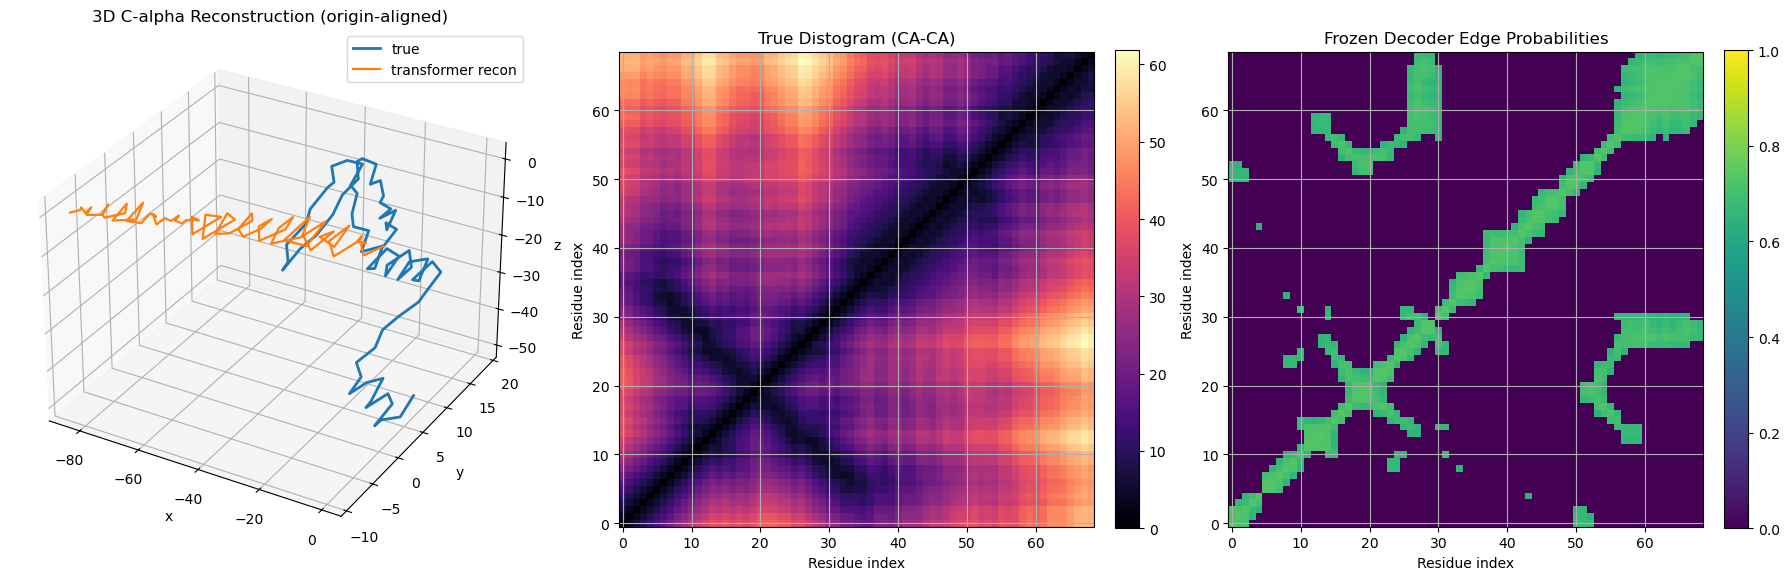

plot_distogram not defined; skipping distogram panel


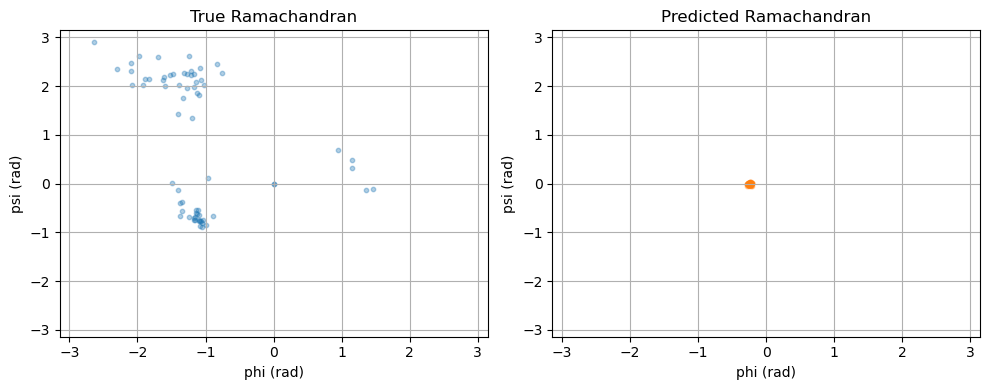

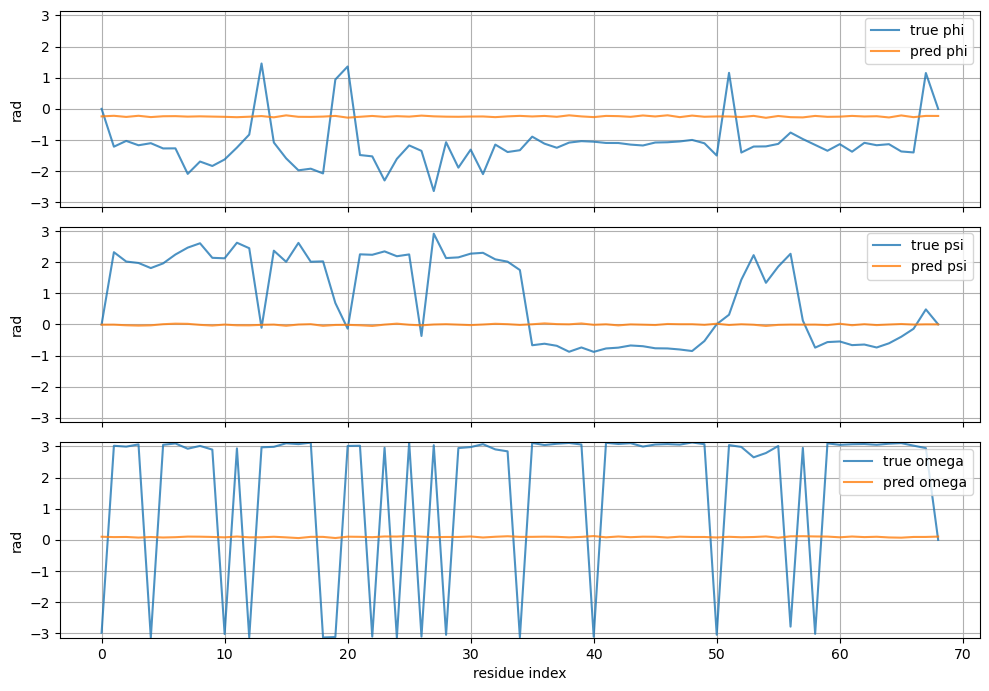

long training epochs:   0%|          | 0/20 [02:39<?, ?it/s]

long epoch 1/20:  12%|#2        | 1237/10045 [02:39<23:40,  6.20it/s, err=_{'fape_quat': 0.0, 'quat_geodesic':…

KeyboardInterrupt: 

In [ ]:
5# Full-dataset run before qualitative inspection.
import math
#import ipython functions for clearing output
from IPython.display import clear_output, display

cfg = globals().get('NB_CFG', {})
long_cfg = cfg.get('long_run', {})
opt_cfg = cfg.get('optim', {})

contact_pair_decoder = globals().get('decoder', None)
if contact_pair_decoder is None:
	raise RuntimeError('Missing pretrained pair decoder `decoder`; run Cell 9 first.')
contact_cfg = cfg.get('contact', {})
contact_threshold = float(globals().get('contact_thresh', contact_cfg.get('threshold_default', 0.6)))
converter_obj = globals().get('converter', pdb_to_graph)

long_num_epochs = int(long_cfg.get('num_epochs', 20))
target_effective_batch_size = int(long_cfg.get('target_effective_batch_size', 10))
use_se3_in_long_run = bool(long_cfg.get('use_se3', False))  # keep False unless SE3 path is stable at your memory budget
long_viz_sample_idx = int(long_cfg.get('viz_sample_idx', 0))       # fixed sample index used for per-epoch reconstruction plots

grad_clip_max_norm = float(opt_cfg.get('grad_clip_max_norm', 1.0))

if '_compute_total_loss' not in globals():
	raise RuntimeError('Run the full training-loop setup cell first to define _compute_total_loss.')

micro_batch_size = int(getattr(train_loader, 'batch_size', 1) or 1)
accum_steps = max(1, math.ceil(target_effective_batch_size / micro_batch_size))
effective_batch_size = micro_batch_size * accum_steps
print(
	f'long loop config: micro_batch_size={micro_batch_size} accum_steps={accum_steps} '
	f'effective_batch_size={effective_batch_size}'
)

transformer_geom_decoder.train()


long_train_params = list(transformer_geom_decoder.parameters())
if use_se3_in_long_run and se3_decoder is not None:
	long_train_params += list(se3_decoder.parameters())
if ('use_uncertainty_weighting' in globals()) and use_uncertainty_weighting and ('kendall_log_vars' in globals()):
	long_train_params += list(kendall_log_vars.parameters())

long_optimizer = torch.optim.AdamW(
	long_train_params,
	lr=float(opt_cfg.get('lr', 3e-4)),
	weight_decay=float(opt_cfg.get('weight_decay', 1e-4)),
)

long_epoch_loss_history = []
long_epoch_se3_skips = []
long_epoch_structures = []
long_epoch_steps = []

nbatch_plot = int(long_cfg.get('plot_every_n_batches', 1000))

def _restore_progress_bars(*bars):
	# clear_output removes rendered tqdm widgets; explicitly re-display/refresh them.
	for bar in bars:
		if bar is None:
			continue
		try:
			if hasattr(bar, 'container'):
				display(bar.container)
			else:
				bar.refresh()
		except Exception:
			try:
				bar.refresh()
			except Exception:
				pass


epoch_pbar = tqdm.tqdm_notebook(range(long_num_epochs), desc='long training epochs', position=0)
for epoch in epoch_pbar:
	running_losses = []
	se3_skip_count = 0
	structures_seen = 0
	step = 0
	last_loss_terms = None

	long_optimizer.zero_grad(set_to_none=True)
	pbar = tqdm.tqdm_notebook(
		train_loader,
		total=len(train_loader),
		desc=f'long epoch {epoch+1}/{long_num_epochs}',
		leave=False,
		position=1,
		dynamic_ncols=True,
	)

	total_loss = torch.tensor(0.0, device=device)
	for batch in pbar:
		
		#if the batch is too long, skip it to avoid OOM; count how many batches were skipped due to length
		if len(batch['res'].x) > 800:
			se3_skip_count += 1
			continue
		
		batch = batch.to(device)

		if ('res' in batch.node_types) and hasattr(batch['res'], 'batch') and (batch['res'].batch is not None):
			structures_in_batch = int(torch.unique(batch['res'].batch).numel())
		else:
			structures_in_batch = micro_batch_size

		loss, _, _, _, _, se3_skip, loss_terms = _compute_total_loss(
			batch, debug_label=f'long_epoch={epoch+1} step={step}'
		)
		last_loss_terms = loss_terms
		if se3_skip:
			se3_skip_count += 1

		total_loss += loss
		running_losses.append(float(loss.detach().cpu()))

		should_step = ((step + 1) % accum_steps == 0)
		if should_step:
			loss_for_step = (total_loss / accum_steps)
			if amp_use_scaler:
				amp_scaler.scale(loss_for_step).backward()
			else:
				loss_for_step.backward()

			if amp_use_scaler:
				amp_scaler.unscale_(long_optimizer)
			torch.nn.utils.clip_grad_norm_(long_train_params, max_norm=grad_clip_max_norm)
			if amp_use_scaler:
				amp_scaler.step(long_optimizer)
				amp_scaler.update()
			else:
				long_optimizer.step()
			long_optimizer.zero_grad(set_to_none=True)
			total_loss = torch.tensor(0.0, device=device)
			torch.cuda.empty_cache()
		structures_seen += structures_in_batch

		if step > 0 and step % nbatch_plot == 0:
			#clear the previous plot to free up memory for the next one
			plt.close('all')
			#ipython clear output to prevent flooding with text during long runs
			clear_output(wait=True)
			_restore_progress_bars(epoch_pbar, pbar)

			print(f'long epoch {epoch+1} step {step}: reconstruction snapshot')
			# Per-epoch reconstruction snapshot on a fixed sample.
			transformer_geom_decoder.eval()
			with torch.no_grad():
				long_viz_sample = struct_dat[long_viz_sample_idx].to(device)
				long_viz_sample = ensure_float32_inplace(long_viz_sample)
				long_viz_sample = ensure_edge_attrs_inplace(long_viz_sample, edge_dim=getattr(encoder, 'edge_dim', 1))

				minimal_long_viz, long_viz_edge_indices, long_viz_edge_probs = build_minimal_contact_graph_batch(
					data_batch=long_viz_sample,
					enc=encoder,
					contact_pair_decoder=contact_pair_decoder,
					threshold=contact_threshold,
					converter_obj=converter_obj,
					device_obj=device,
				)
				z_long_viz = minimal_long_viz['res'].x
				long_viz_sample['res'].x = z_long_viz

				out_long_viz = transformer_geom_decoder(
					minimal_long_viz,
					contact_pred_index=long_viz_edge_indices,
					contact_probs=long_viz_edge_probs,
				)
				_, _, _, viz_true_angles, viz_true_coords, viz_batch_idx, _ = get_true_geometry(long_viz_sample)
				long_viz_pred_rt = out_long_viz['rt_pred']
				long_viz_pred_q = out_long_viz.get('quat_unit_pred', long_viz_pred_rt[..., :4])
				long_viz_pred_t = out_long_viz.get('trans_pred', long_viz_pred_rt[..., 4:])
				long_viz_pred_R = out_long_viz.get('rotmat_pred', quaternion_to_rotation_matrix(long_viz_pred_q))
				viz_pred_angles = out_long_viz.get('angles')
				long_viz_pred_coords = out_long_viz.get('trans_coords_pred', None)
				
				#plot the coord reconstruction from the se3 decoder if it is available
				
					
			print(f'long epoch {epoch+1}: reconstruction snapshot')
			plot_3d_reconstruction(viz_true_coords, long_viz_pred_coords, None, edge_indices=long_viz_edge_indices, edge_probs=long_viz_edge_probs)
			plot_ramachandran(viz_true_angles, viz_pred_angles)
			plot_angle_traces(viz_true_angles, viz_pred_angles)
			#plot the distogram if true coords are available
			if viz_true_coords is not None:
				plot_distogram(viz_true_coords, long_viz_pred_coords) if 'plot_distogram' in globals() else print('plot_distogram not defined; skipping distogram panel')

			plt.show()

			_restore_progress_bars(epoch_pbar, pbar)
		step += 1

		pbar.set_postfix(_loss_postfix(loss_terms))

	# Flush remaining gradients if epoch ended mid-accumulation.
	if step > 0 and (step % accum_steps != 0):
		remaining_steps = max(1, step % accum_steps)
		loss_for_step = (total_loss / remaining_steps)
		if amp_use_scaler:
			amp_scaler.scale(loss_for_step).backward()
		else:
			loss_for_step.backward()

		if amp_use_scaler:
			amp_scaler.unscale_(long_optimizer)
		torch.nn.utils.clip_grad_norm_(long_train_params, max_norm=grad_clip_max_norm)
		if amp_use_scaler:
			amp_scaler.step(long_optimizer)
			amp_scaler.update()
		else:
			long_optimizer.step()
		long_optimizer.zero_grad(set_to_none=True)
		#clear cuda cache to prevent potential OOM in next epoch if we had a large final micro-batch
		torch.cuda.empty_cache()
	
	
	pbar.close()

	if len(running_losses) == 0:
		raise RuntimeError('Long run got zero batches; check loader configuration.')

	epoch_mean = float(np.mean(running_losses))
	long_epoch_loss_history.append(epoch_mean)
	long_epoch_se3_skips.append(se3_skip_count)
	long_epoch_structures.append(structures_seen)
	long_epoch_steps.append(step)
	epoch_postfix = _loss_postfix(last_loss_terms)
	epoch_postfix['mean_loss'] = f'{epoch_mean:.4f}'
	epoch_pbar.set_postfix(epoch_postfix)
	print(
		f'long_epoch={epoch+1}/{long_num_epochs} steps={step} structures={structures_seen} '
		f'mean_loss={epoch_mean:.6f} se3_skips={se3_skip_count} accum_steps={accum_steps}'
	)
	if ('use_uncertainty_weighting' in globals()) and use_uncertainty_weighting and ('kendall_log_vars' in globals()):
		print('kendall sigmas:', {k: float(torch.exp(0.5 * v).detach().cpu()) for k, v in kendall_log_vars.items()})
	#print the different losses if they are available in the current epoch
	
	# Per-epoch reconstruction snapshot on a fixed sample.
	transformer_geom_decoder.eval()
	se3_decoder.eval() if se3_decoder is not None else None
	with torch.no_grad():
		long_viz_sample = struct_dat[long_viz_sample_idx].to(device)
		long_viz_sample = ensure_float32_inplace(long_viz_sample)
		long_viz_sample = ensure_edge_attrs_inplace(long_viz_sample, edge_dim=getattr(encoder, 'edge_dim', 1))

		minimal_long_viz, long_viz_edge_indices, long_viz_edge_probs = build_minimal_contact_graph_batch(
			data_batch=long_viz_sample,
			enc=encoder,
			contact_pair_decoder=contact_pair_decoder,
			threshold=contact_threshold,
			converter_obj=converter_obj,
			device_obj=device,
		)
		z_long_viz = minimal_long_viz['res'].x
		long_viz_sample['res'].x = z_long_viz

		out_long_viz = transformer_geom_decoder(
			minimal_long_viz,
			contact_pred_index=long_viz_edge_indices,
			contact_probs=long_viz_edge_probs,
		)
		_, _, _, viz_true_angles, viz_true_coords, viz_batch_idx, _ = get_true_geometry(long_viz_sample)
		long_viz_pred_rt = out_long_viz['rt_pred']
		long_viz_pred_q = out_long_viz.get('quat_unit_pred', long_viz_pred_rt[..., :4])
		long_viz_pred_t = out_long_viz.get('trans_pred', long_viz_pred_rt[..., 4:])
		long_viz_pred_R = out_long_viz.get('rotmat_pred', quaternion_to_rotation_matrix(long_viz_pred_q))
		long_viz_pred_coords = reconstruct_positions_quat_composed(
			long_viz_pred_R,
			long_viz_pred_t,
			batch_idx=viz_batch_idx,
			include_origin=False,
		)

	print(f'long epoch {epoch+1}: reconstruction snapshot')
	plot_3d_reconstruction(viz_true_coords, long_viz_pred_coords, None, edge_indices=long_viz_edge_indices, edge_probs=long_viz_edge_probs)
	
	transformer_geom_decoder.train()
	if se3_decoder is not None:
		se3_decoder.train()


print('use_se3_in_long_run:', use_se3_in_long_run)
print('long_epoch_loss_history:', long_epoch_loss_history)
print('long_epoch_se3_skips:', long_epoch_se3_skips)
print('long_epoch_structures:', long_epoch_structures)
print('long_epoch_steps:', long_epoch_steps)

In [ ]:
# One-batch finite diagnostics for unified frame outputs.
with torch.no_grad():
	dbg_batch = next(iter(train_loader)).to(device)
	dbg_batch = ensure_float32_inplace(dbg_batch)
	dbg_batch = ensure_edge_attrs_inplace(dbg_batch, edge_dim=getattr(encoder, 'edge_dim', 1))

	contact_pair_decoder = globals().get('decoder', None)
	if contact_pair_decoder is None:
		raise RuntimeError('Missing pretrained pair decoder `decoder`; run Cell 9 first.')
	cfg = globals().get('NB_CFG', {})
	contact_cfg = cfg.get('contact', {})
	contact_threshold = float(globals().get('contact_thresh', contact_cfg.get('threshold_default', 0.6)))
	converter_obj = globals().get('converter', pdb_to_graph)

	minimal_dbg, dbg_edge_indices, dbg_edge_probs = build_minimal_contact_graph_batch(
		data_batch=dbg_batch,
		enc=encoder,
		contact_pair_decoder=contact_pair_decoder,
		threshold=contact_threshold,
		converter_obj=converter_obj,
		device_obj=device,
	)

	out_dbg = transformer_geom_decoder(
		minimal_dbg,
		contact_pred_index=dbg_edge_indices,
		contact_probs=dbg_edge_probs,
	)
	true_R_dbg, true_t_dbg, true_q_dbg, true_angles_dbg, true_coords_dbg, batch_idx_dbg, plddt_dbg = get_true_geometry(dbg_batch)

	pred_rt_dbg = out_dbg['rt_pred']
	pred_q_dbg = out_dbg.get('quat_unit_pred', pred_rt_dbg[..., :4])
	pred_t_steps_dbg = out_dbg.get('trans_steps_pred', out_dbg.get('trans_pred', pred_rt_dbg[..., 4:]))
	pred_t_coords_dbg = out_dbg.get('trans_coords_pred', None)
	pred_R_dbg = out_dbg.get('rotmat_pred', quaternion_to_rotation_matrix(pred_q_dbg))
	pred_angles_dbg = out_dbg.get('angles')
	if pred_t_coords_dbg is None:
		pred_coords_dbg = reconstruct_positions_quat_composed(pred_R_dbg, pred_t_steps_dbg, batch_idx=minimal_dbg['res'].batch, include_origin=False)
	else:
		pred_coords_dbg = pred_t_coords_dbg

	def _finite_ratio(x):
		if x is None:
			return None
		return float(torch.isfinite(x).float().mean().detach().cpu())

	print('dbg selected contact edges:', int(dbg_edge_indices.shape[1]))
	print('finite_ratio true_q     :', _finite_ratio(true_q_dbg))
	print('finite_ratio true_coords:', _finite_ratio(true_coords_dbg))
	print('finite_ratio true_angles:', _finite_ratio(true_angles_dbg))
	print('finite_ratio pred_rt    :', _finite_ratio(pred_rt_dbg))
	print('finite_ratio pred_q     :', _finite_ratio(pred_q_dbg))
	print('finite_ratio pred_t_steps:', _finite_ratio(pred_t_steps_dbg))
	print('finite_ratio pred_R     :', _finite_ratio(pred_R_dbg))
	print('finite_ratio pred_coords:', _finite_ratio(pred_coords_dbg))
	print('finite_ratio pred_angles:', _finite_ratio(pred_angles_dbg))
	print('pred_rt abs max         :', float(torch.nan_to_num(pred_rt_dbg).abs().max().detach().cpu()))

dbg selected contact edges: 117867
finite_ratio true_q     : 1.0
finite_ratio true_coords: 1.0
finite_ratio true_angles: 1.0
finite_ratio pred_rt    : 1.0
finite_ratio pred_q     : 1.0
finite_ratio pred_t_steps: 1.0
finite_ratio pred_R     : 1.0
finite_ratio pred_coords: 1.0
finite_ratio pred_angles: 1.0
pred_rt abs max         : 0.9129796028137207


/tmp/ipykernel_1620504/923714356.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  minimal['res', 'contact_proba', 'res'].edge_index = torch.tensor(edge_indices.detach().clone(), dtype=torch.long, device=device_obj)


In [ ]:
# One-step loss smoke test after NaN guard patch.
_smoke_batch = next(iter(train_loader)).to(device)
_smoke_total, _, _, _, _, _, _smoke_terms = _compute_total_loss(_smoke_batch, debug_label='smoke_after_nan_patch')
print('smoke total loss finite:', bool(torch.isfinite(_smoke_total).all().item()), 'value:', float(_smoke_total.detach().cpu()))
print('smoke loss terms:', {k: _smoke_terms[k] for k in sorted(_smoke_terms.keys())})

smoke total loss finite: True value: 21.11881446838379
smoke loss terms: {'angles': 0.0, 'fape_quat': 0.0, 'lddt_coords': 0.0, 'neighbor': 21.11881446838379, 'quat_geodesic': 0.0, 'total': 21.11881446838379}


/tmp/ipykernel_1620504/923714356.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  minimal['res', 'contact_proba', 'res'].edge_index = torch.tensor(edge_indices.detach().clone(), dtype=torch.long, device=device_obj)


## Notes
- If you have a pretrained encoder checkpoint, set `PRETRAINED_ENCODER_PATH` and rerun.
- The smoke loop is intentionally short and diagnostics-first.
- Extend with longer runs only after losses are finite and reconstructions are visually sensible.


In [ ]:
# Visualize a reconstruction snapshot from the trained decoder(s).
import torch

required_globals = [
    'encoder',
    'transformer_geom_decoder',
    'struct_dat',
    'device',
    'ensure_float32_inplace',
    'ensure_edge_attrs_inplace',
    'get_true_geometry',
    'quaternion_to_rotation_matrix',
    'reconstruct_positions',
    'plot_ramachandran',
    'plot_angle_traces',
    'plot_3d_reconstruction',
]
missing = [name for name in required_globals if name not in globals()]
if missing:
    raise RuntimeError(
        'Missing required objects for reconstruction visualization. '
        f'Run the training/setup cells first. Missing: {missing}'
    )

cfg = globals().get('NB_CFG', {})
viz_sample_idx = int(cfg.get('viz', {}).get('sample_idx', 0))  # change this index to inspect a different structure

encoder.eval()
transformer_geom_decoder.eval()
if 'se3_decoder' in globals() and se3_decoder is not None:
    se3_decoder.eval()

with torch.no_grad():
    sample = struct_dat[viz_sample_idx].to(device)
    sample = ensure_float32_inplace(sample)
    sample = ensure_edge_attrs_inplace(sample, edge_dim=getattr(encoder, 'edge_dim', 1))

    plot_edge_indices = None
    plot_edge_probs = None
    contact_pair_decoder = globals().get('decoder', None)
    if contact_pair_decoder is not None and 'build_minimal_contact_graph_batch' in globals() and 'converter' in globals():
        try:
            contact_cfg = cfg.get('contact', {})
            contact_threshold = float(globals().get('contact_thresh', contact_cfg.get('threshold_default', 0.6)))
            _, plot_edge_indices, plot_edge_probs = build_minimal_contact_graph_batch(
                data_batch=sample.clone(),
                enc=encoder,
                contact_pair_decoder=contact_pair_decoder,
                threshold=contact_threshold,
                converter_obj=converter,
                device_obj=device,
            )
        except Exception as exc:
            print(f'Edge-probability overlay unavailable: {exc}')

    z_viz, _ = encoder(sample)
    sample['res'].x = z_viz

    out_t = transformer_geom_decoder(sample, contact_pred_index=None)

    geo = get_true_geometry(sample)
    if len(geo) == 7:
        _, _, _, true_angles, true_coords, batch_idx, _ = geo
    else:
        _, _, _, true_angles, true_coords, batch_idx = geo

    pred_rt = out_t['rt_pred']
    pred_q_raw = pred_rt[..., :4]
    pred_q = out_t.get('quat_unit_pred', pred_q_raw / torch.clamp(torch.norm(pred_q_raw, dim=-1, keepdim=True), min=1e-8))
    pred_t = out_t.get('trans_pred', pred_rt[..., 4:])
    pred_R = out_t.get('rotmat_pred', quaternion_to_rotation_matrix(pred_q))

    # Keep both versions for diagnostics.
    pred_coords_translation_only = reconstruct_positions(
        pred_R,
        pred_t,
        batch_idx=batch_idx,
        translation_frame='global',
        include_origin=False,
    )
    pred_t_local = out_t.get('trans_local_pred', torch.einsum('nij,nj->ni', pred_R.transpose(-1, -2), pred_t))
    pred_coords = reconstruct_positions(
        pred_R,
        pred_t_local,
        batch_idx=batch_idx,
        translation_frame='local',
        include_origin=False,
    )
    pred_angles = out_t.get('angles')

    se3_coords = None
    if 'se3_decoder' in globals() and se3_decoder is not None:
        try:
            sample['coord_pred'].x = pred_coords
            out_s = se3_decoder(sample)
            c = out_s.get('coors_out')
            if c is not None:
                if c.ndim == 3 and batch_idx is not None:
                    parts = []
                    unique_batches = torch.unique(batch_idx, sorted=True)
                    for i, b in enumerate(unique_batches):
                        n = int((batch_idx == b).sum().item())
                        parts.append(c[i, :n])
                    se3_coords = torch.cat(parts, dim=0)
                elif c.ndim == 3:
                    se3_coords = c[0]
                else:
                    se3_coords = c
                if true_coords is not None:
                    se3_coords = se3_coords.to(true_coords.device, dtype=true_coords.dtype)
        except Exception as exc:
            print(f'SE3 reconstruction skipped due to runtime error: {exc}')

def _planarity_ratio(coords: torch.Tensor) -> float:
    if coords is None or coords.ndim != 2 or coords.shape[-1] != 3 or coords.shape[0] < 3:
        return float('nan')
    x = coords - coords.mean(dim=0, keepdim=True)
    s = torch.linalg.svdvals(x)
    return float((s[-1] / torch.clamp(s[0], min=1e-8)).detach().cpu())

print(f'Visualization sample index: {viz_sample_idx}')
print('true_coords shape:', None if true_coords is None else tuple(true_coords.shape))
print('pred_coords (quat-composed) shape:', tuple(pred_coords.shape))
print('pred_coords (translation-only) shape:', tuple(pred_coords_translation_only.shape))
print('se3_coords shape :', None if se3_coords is None else tuple(se3_coords.shape))
print('planarity ratio true                 :', _planarity_ratio(true_coords))
print('planarity ratio pred quat-composed  :', _planarity_ratio(pred_coords))
print('planarity ratio pred translation-only:', _planarity_ratio(pred_coords_translation_only))

plot_ramachandran(true_angles, pred_angles)
plot_angle_traces(true_angles, pred_angles)
plot_3d_reconstruction(true_coords, pred_coords, se3_coords, edge_indices=plot_edge_indices, edge_probs=plot_edge_probs)